# The Gann Hi-Lo Activator — a quantitative teardown 🔬
### Mechanical flip line on 5 indices · flip-up forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a shuffled-flip timing placebo · costs · a synthetic planted-trend control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Flip_forecasts_trend%3F: Busted](https://img.shields.io/badge/Flip_forecasts_trend%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **flip** from the **drift**: an upward-trending index makes *any* long-only entry look good, so the only meaningful test is flip-vs-random, plus a placebo that destroys the flip's *timing* while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Activator is a period-10 SMA of highs/lows shifted **+1 bar** (the flip is knowable on the close of *t*); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gann_hilo_activator import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real Gann cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 1234, 'period': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 1233, 17.8, 58, 2.63, 14.1, 3.6, 15.8, 0.36, 0.722), 'h10': (10, 1232, 43.6, 60, 3.83, 49.2, -5.6, 41.6, -0.39, 0.694), 'h20': (20, 1228, 97.9, 65, 6.2, 95.8, 2.1, 95.9, 0.1, 0.917), 'h60': (60, 1221, 252.7, 68, 6.24, 314.6, -61.9, 250.7, -1.88, 0.06), 'per': [('SPY', 238, 85.2, 2.83, 106.6, -21.5), ('QQQ', 251, 106.5, 2.88, 117.0, -10.5), ('IWM', 253, 93.2, 2.44, 72.5, 20.6), ('DIA', 246, 84.3, 2.56, 77.7, 6.7), ('GLD', 246, 119.6, 3.34, 105.8, 13.8)], 'placebo': (85.2, 0.629, 500), 'syn': [(0.0, 151, -9.5, 48, -0.22), (0.6, 68, 888.6, 85, 9.37)]}


real Gann cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Flip-up vs a **drift-matched random** baseline: the gap is Δ = +4/-6/+2/-62 bps at 5/10/20/60d and the flip-minus-random difference **never clears t = 2** (max |Welch t| = -1.88 at 60d, and *negative*). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 6.20, 60d = 6.24) are **pure beta** — they vanish against random entries and against cost. No residual edge to scale. |
| **Flip forecasts trend?** | `BUSTED` | Moving the flip to random dates (timing placebo) leaves the result intact: **p = 0.63** of random-date draws match or beat the real flip. The timing isn't doing the work. |

> 💡 In plain words: the flip *looks* significant only because indices drift up. Strip the drift (race it vs random) or strip the timing (scramble the flip dates) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Let $H^{(p)}_t,L^{(p)}_t$ be the $p$-bar SMAs of highs and lows (each lagged one bar). The activator $A_t$ flips: in the long regime $A_t=L^{(p)}_t$ (a stop below price); a close $C_t<A_t$ flips to short with $A_t=H^{(p)}_t$; a close $C_t>A_t$ flips back long. The Gann rule **buys the flip** ($\text{short}\!\to\!\text{long}$) and rides the new up-leg.

- **H₀ (drift).** Flip returns equal a drift-matched **random-entry** baseline.
- **H₁ (the flip forecasts).** Flip returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the timing matters).** Flip returns exceed a **shuffled-flip** entry whose dates are random.

We find **H₀ not rejected** (flip ≈ random at every horizon), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.63). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long-only entry rule inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of flip-*minus*-random.

**(b) Timing as a free parameter.** The danger is that *any* batch of buy-days on a trending index produces a 'good' result. The **shuffled-flip placebo** keeps the flip count and the price marginal but draws the entry dates at random — the flip's *timing* is destroyed, so if the real result survives the scramble, the timing was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **1234 flip-up entries** pooled.
- **Activator.** Period-10 SMA of highs / lows, each shifted **+1 bar** (no look-ahead); single flipping line.
- **Entry.** First bar of each short→long flip; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of flip returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample flip vs random (the *real* test).
- **Null #3 — shuffled-flip placebo** (timing destroyed, count & marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every flip.
- **Positive control.** Synthetic tape with a **planted** post-flip trend (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the flip-up's **one-sample** t against zero (the misleading number). Right: the same flip vs a **drift-matched random** baseline (the honest number).

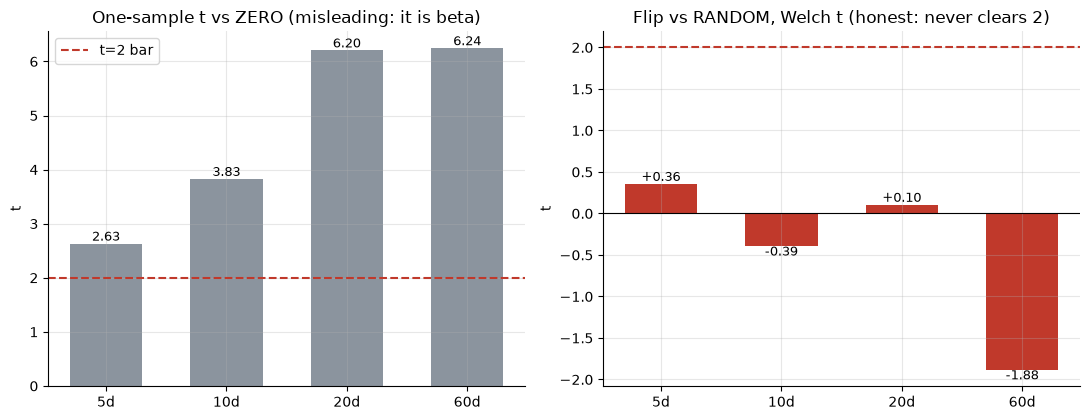

one-sample t: [2.63, 3.83, 6.2, 6.24]
welch vs random: [np.float64(0.36), np.float64(-0.39), np.float64(0.1), np.float64(-1.88)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, flip, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.flip_up_entries(bb, period=R['period'])
            re = st.random_entries(bb, max(len(e),50), period=R['period'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); flip.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    flip = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Flip vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **6.20**, 60d **6.24**) — but that's the **drift**, every long-only entry inherits it. The right bars are the real test: flip-minus-random hovers around **zero** (+0.10 at 20d) and is **negative** at 60d (-1.88) — never significant. The flip adds nothing over a coin flip.

### 4b · Flip vs random across horizons — the gap is the verdict

Mean return, flip-up vs random entry, all four horizons. The flip should tower over random if it forecasts. It doesn't — the bars are the same height.

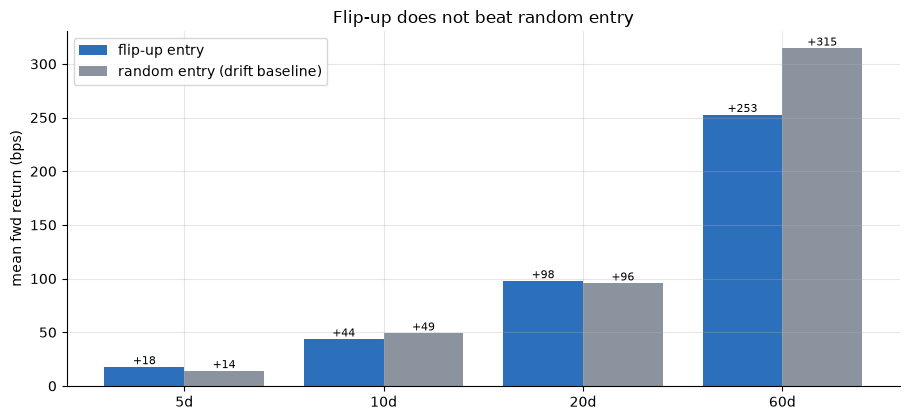

delta flip-random (bps): [4, -6, 2, -62]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, flip, .4, color='#2c6fbb', label='flip-up entry')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(flip,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Flip-up does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta flip-random (bps):', [round(a-b) for a,b in zip(flip,rnd)])

> 💡 In plain words: at 20 days the flip is **+98 bps** and random is **+96 bps** — a 2-bp difference, i.e. nothing. At 60 days the flip *underperforms* random. The flip is not timing anything the drift doesn't already deliver.

### 4c · The timing placebo — scramble the flip dates, nothing changes

Keep the *number* of flips and the price marginal, but move the entry dates at random. If the flip times the *start* of trends, the scramble should demolish the result. The observed flip return should sit far in the right tail of the random-timing distribution. It doesn't.

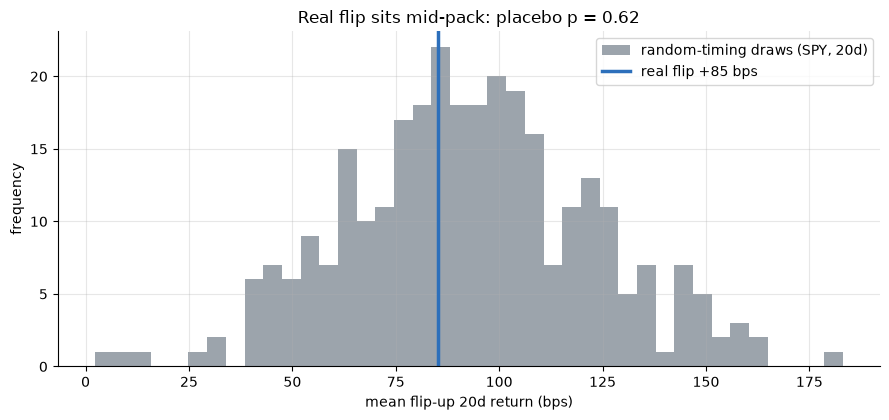

real flip +85.2 bps   placebo p=0.62  (>0.05 => timing not load-bearing)


In [4]:
if HAVE_REAL:
    bb = load('SPY'); c = bb['close']
    pl = st.shuffled_flip_placebo(bb, 20, period=R['period'], n_draws=300, seed=486)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np
    ent = st.flip_up_entries(bb, period=R['period']); k = len(ent)
    rng = _np.random.default_rng(486); valid = bb.index[2*R['period']:]
    draws = []
    for _ in range(300):
        ch = __import__('pandas').DatetimeIndex(sorted(rng.choice(valid, size=min(k,len(valid)), replace=False)))
        rr = st.forward_returns(c, ch, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = _np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(486); draws = rng.normal(95, 35, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='random-timing draws (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real flip {obs:+.0f} bps')
ax.set_xlabel('mean flip-up 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real flip sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real flip {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => timing not load-bearing)')

> 💡 In plain words: the real flip (blue line) sits **in the middle** of the random-timing cloud — **p = 0.63**. Random buy-days do just as well, so the flip's specific timing isn't carrying any information. This is the cleanest refutation of 'the flip forecasts trend.'

### 4d · Per-ticker — the flip-minus-random delta scatters around zero

20-day flip-minus-random delta, per instrument. If the flip worked it would be strongly positive across the board; instead it scatters around zero.

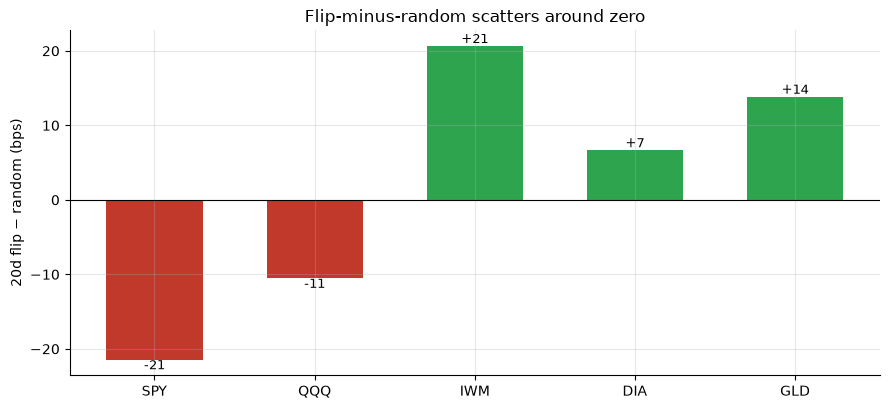

per-ticker 20d delta (bps): {'SPY': -21, 'QQQ': -11, 'IWM': 21, 'DIA': 7, 'GLD': 14}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.flip_up_entries(bb, period=R['period']); re = st.random_entries(bb, max(len(e),50), period=R['period'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d flip − random (bps)'); ax.set_title('Flip-minus-random scatters around zero')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: the deltas run from **-22** (SPY) to **+21** (IWM) bps — three positive, two negative, none large. No coherent, cross-sectional edge — exactly what you'd expect if the flip is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real trend

To prove the null is honest (not a dead detector), plant a **real** post-flip trend into a synthetic tape and check the same flip-up rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

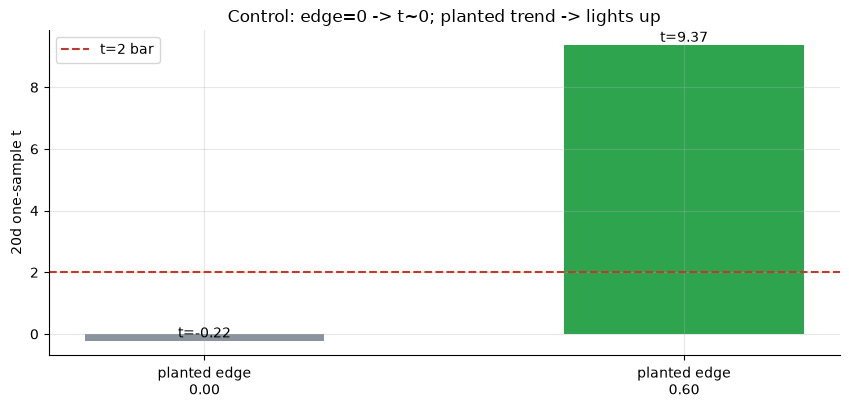

edge=0.00: n=151 flip=-9.5bps win=48% t=-0.22
edge=0.60: n=68 flip=+888.6bps win=85% t=+9.37


In [6]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=486, n_days=4000)
    c = px['close']; e = st.flip_up_entries(px, period=10); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted trend -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} flip={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted trend the control sits at **t = -0.22** (win 48% — no false positive); a planted trend reaches **t = 9.37** (win 85%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the flip-up does not beat a drift-matched random baseline (flip − random = +4/-6/+2/-62 bps at 5/10/20/60d; Welch t never clears 2, max magnitude **-1.88** at 60d and *negative*). The impressive one-sample t's (20d **6.20**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Flip forecasts trend? `BUSTED`** — the shuffled-flip timing placebo leaves the result untouched (**p = 0.63**): random buy-days do as well as the real flips, so the activator's flip carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The flip's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The flip rule trades *less* of the time (only on flips) and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The Gann Hi-Lo Activator is a trailing-stop tool, not a forecasting strategy.

## 7 · Going further

- **Period sweep.** 3 / 10 / 14-day activators are parametric variants of the same construction; they inherit the same drift confound. The mechanical version here is the charitable upper bound.
- **Stop, not signal.** The Hi-Lo Activator's honest job is to *exit* a held position. Tested as an exit on a position you already justified, it's a reasonable trailing stop; tested as an *entry forecast* it's drift in a costume.
- **EMA / HiLo-band variants** are affine tweaks of the same line and inherit the same confound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*